Loading The Data

In [4]:
import pandas as pd
df1 = pd.read_csv("Steel_industry_data.csv") 

Exploratory Data Analysis (EDA)

In [5]:
df1.head(10)

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load
5,01/01/2018 01:30,3.28,3.56,0.0,0.0,67.76,100.0,5400,Weekday,Monday,Light_Load
6,01/01/2018 01:45,3.60,4.14,0.0,0.0,65.62,100.0,6300,Weekday,Monday,Light_Load
7,01/01/2018 02:00,3.60,4.28,0.0,0.0,64.37,100.0,7200,Weekday,Monday,Light_Load
8,01/01/2018 02:15,3.28,3.64,0.0,0.0,66.94,100.0,8100,Weekday,Monday,Light_Load
9,01/01/2018 02:30,3.78,4.72,0.0,0.0,62.51,100.0,9000,Weekday,Monday,Light_Load


In [8]:
df1["date"].unique()

array(['01/01/2018 00:15', '01/01/2018 00:30', '01/01/2018 00:45', ...,
       '31/12/2018 23:30', '31/12/2018 23:45', '31/12/2018 00:00'],
      shape=(35040,), dtype=object)

In [43]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                             35040 non-null  object 
dtypes: float64(6), 

In [10]:
df2 = df1.drop('date', axis=1)

In [11]:
df2.head()

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


In [12]:
df2.columns

Index(['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'WeekStatus', 'Day_of_week', 'Load_Type'],
      dtype='object')

In [16]:
df2[['Lagging_Current_Reactive.Power_kVarh', 
    'Leading_Current_Reactive_Power_kVarh',
    'Lagging_Current_Power_Factor', 
    'Leading_Current_Power_Factor']].describe()

,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,Lagging_Current_Power_Factor,Leading_Current_Power_Factor
count,35040.000000,35040.000000,35040.000000,35040.000000
mean,13.035384,3.870949,80.578056,84.367870
std,16.306000,7.424463,18.921322,30.456535
min,0.000000,0.000000,0.000000,0.000000
25%,2.300000,0.000000,63.320000,99.700000
50%,5.000000,0.000000,87.960000,100.000000
75%,22.640000,2.090000,99.022500,100.000000
max,96.910000,27.760000,100.000000,100.000000


In [17]:
df2.groupby('Load_Type')[['Lagging_Current_Power_Factor', 
                          'Leading_Current_Power_Factor']].mean()

,Lagging_Current_Power_Factor,Leading_Current_Power_Factor
Load_Type,,
Light_Load,69.679545,85.409154
Maximum_Load,91.013417,95.725678
Medium_Load,93.064849,73.908705


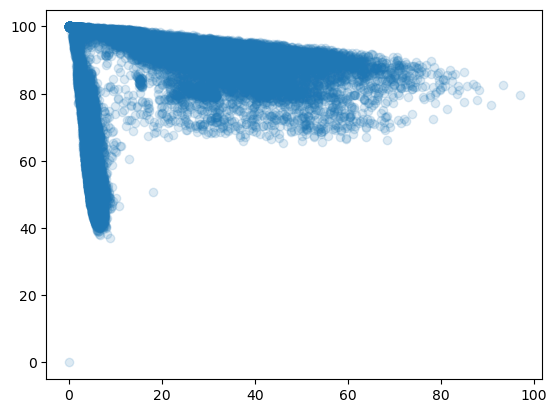

In [18]:
import matplotlib.pyplot as plt
plt.scatter(df2['Lagging_Current_Reactive.Power_kVarh'], 
            df2['Lagging_Current_Power_Factor'], alpha=0.15)

In [19]:
df2.groupby('WeekStatus')[['Lagging_Current_Power_Factor',
                           'Leading_Current_Power_Factor']].mean()

,Lagging_Current_Power_Factor,Leading_Current_Power_Factor
WeekStatus,,
Weekday,79.932112,90.417555
Weekend,82.199129,69.185488


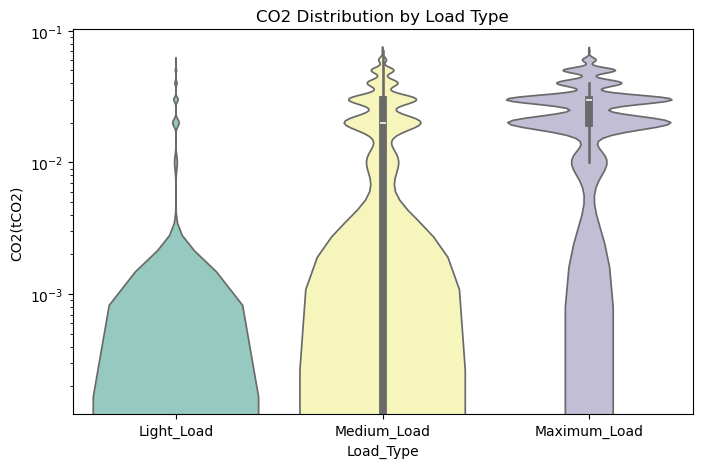

In [23]:
import seaborn as sns
plt.figure(figsize=(8,5))
sns.violinplot(x='Load_Type', y='CO2(tCO2)', data=df2, hue='Load_Type', palette='Set3', legend=False)

plt.yscale('log')
plt.title('CO2 Distribution by Load Type')
plt.show()

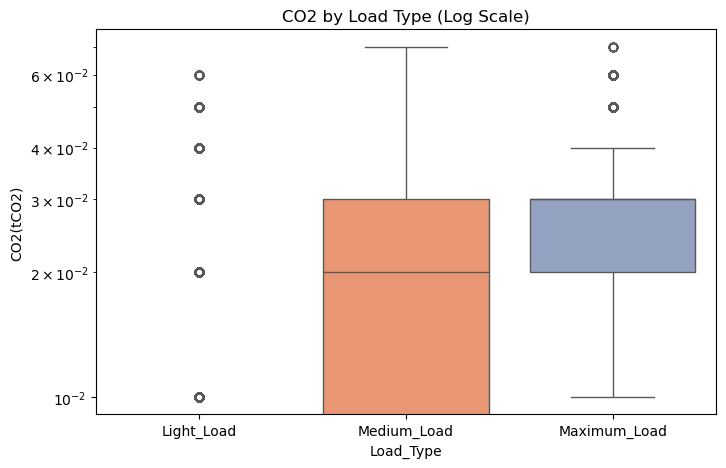

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Load_Type', y='CO2(tCO2)', data=df2, hue='Load_Type', palette='Set2', legend=False)

plt.yscale('log')  
plt.title('CO2 by Load Type (Log Scale)')
plt.show()

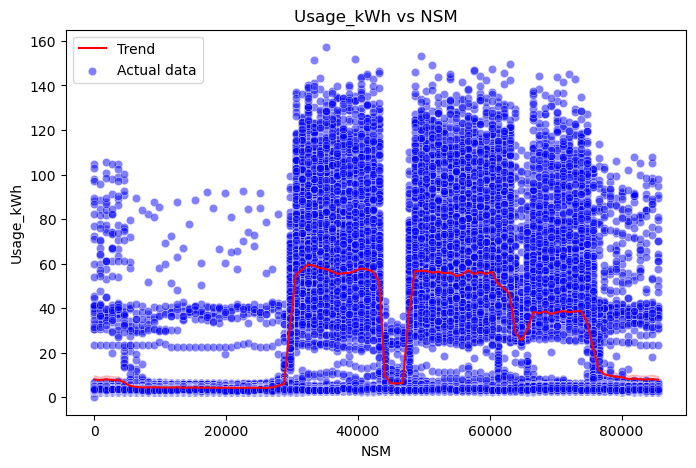

In [24]:
plt.figure(figsize=(8,5))

sns.lineplot(
    x='NSM',
    y='Usage_kWh',
    data=df2,
    color='red',
    label='Trend'
)

sns.scatterplot(
    x='NSM',
    y='Usage_kWh',
    data=df2,
    alpha=0.5,
    color='blue',
    label='Actual data'
)

plt.legend()
plt.title('Usage_kWh vs NSM')
plt.show()

In [27]:
df2["Day_of_week"].value_counts()

Day_of_week
Monday       5088
Tuesday      4992
Wednesday    4992
Thursday     4992
Friday       4992
Saturday     4992
Sunday       4992
Name: count, dtype: int64

<Axes: xlabel='Day_of_week'>

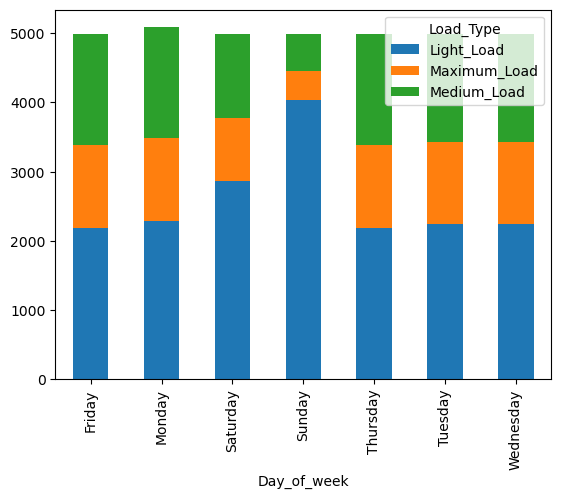

In [28]:
pd.crosstab(df2['Day_of_week'], df2['Load_Type']).plot(kind='bar', stacked=True)

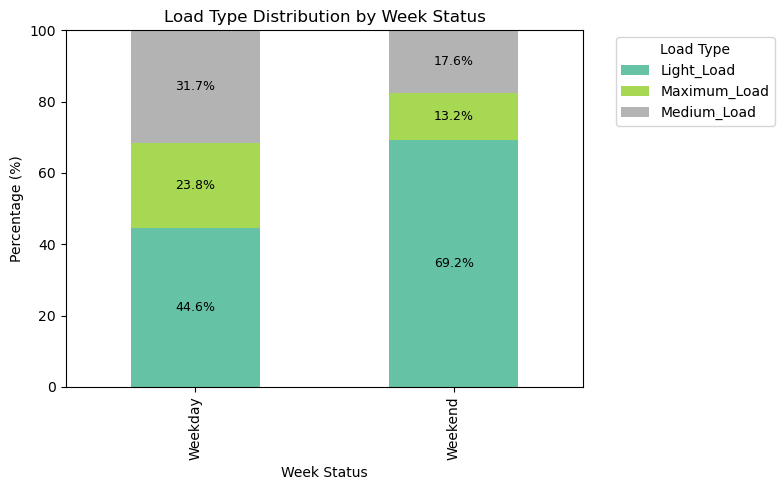

In [29]:
table = pd.crosstab(df2['WeekStatus'], df2['Load_Type'])

table_pct = table.div(table.sum(axis=1), axis=0) * 100

ax = table_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5),
    colormap='Set2'
)

plt.title('Load Type Distribution by Week Status')
plt.xlabel('Week Status')
plt.ylabel('Percentage (%)')
plt.legend(title='Load Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 100)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=9)

plt.tight_layout()
plt.show()

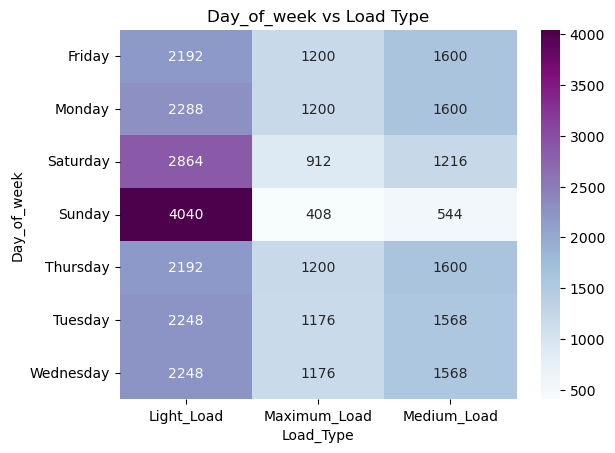

In [30]:
table = pd.crosstab(df2['Day_of_week'], df2['Load_Type'])

sns.heatmap(table, annot=True, cmap='BuPu', fmt='d')
plt.title('Day_of_week vs Load Type')
plt.show()

<Axes: xlabel='Load_Type', ylabel='count'>

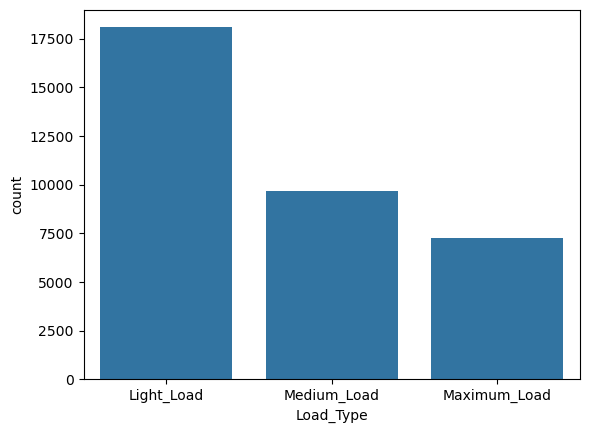

In [31]:
sns.countplot(x='Load_Type', data=df2)

In [32]:
df2.head()

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


Data preprocessing and Feature Engineering

In [47]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

encoder.classes_ = np.array(['Light_Load', 'Medium_Load', 'Maximum_Load'])

df2['Load_Encoded'] = encoder.transform(df2['Load_Type'])

print(df2.head())

   Usage_kWh  Lagging_Current_Reactive.Power_kVarh  \
0       3.17                                  2.95   
1       4.00                                  4.46   
2       3.24                                  3.28   
3       3.31                                  3.56   
4       3.82                                  4.50   

   Leading_Current_Reactive_Power_kVarh  CO2(tCO2)  \
0                                   0.0        0.0   
1                                   0.0        0.0   
2                                   0.0        0.0   
3                                   0.0        0.0   
4                                   0.0        0.0   

   Lagging_Current_Power_Factor  Leading_Current_Power_Factor   NSM  \
0                         73.21                         100.0   900   
1                         66.77                         100.0  1800   
2                         70.28                         100.0  2700   
3                         68.09                         100.0  360

In [34]:
df2['Load_Encoded'].value_counts()

Load_Encoded
0    18072
1     9696
2     7272
Name: count, dtype: int64

In [35]:
df2['Load_Type'].value_counts()

Load_Type
Light_Load      18072
Medium_Load      9696
Maximum_Load     7272
Name: count, dtype: int64

In [36]:
df2.head()

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,Load_Encoded
0,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,0
1,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,0
2,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,0
3,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,0
4,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,0


In [37]:
df3 = df2.drop(columns= ['Day_of_week', 'Load_Type'])

In [38]:
df3.head()

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Load_Encoded
0,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,0
1,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,0
2,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,0
3,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,0
4,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,0


In [45]:
from sklearn.preprocessing import OneHotEncoder

categorical_cols = ['WeekStatus']

encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
)

encoded = encoder.fit_transform(df3[categorical_cols])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=df3.index
)


df3_encoded = pd.concat(
    [df3.drop(columns=categorical_cols), encoded_df],
    axis=1
)

print(df3_encoded)

       Usage_kWh  Lagging_Current_Reactive.Power_kVarh  \
0           3.17                                  2.95   
1           4.00                                  4.46   
2           3.24                                  3.28   
3           3.31                                  3.56   
4           3.82                                  4.50   
...          ...                                   ...   
35035       3.85                                  4.86   
35036       3.74                                  3.74   
35037       3.78                                  3.17   
35038       3.78                                  3.06   
35039       3.67                                  3.02   

       Leading_Current_Reactive_Power_kVarh  CO2(tCO2)  \
0                                      0.00        0.0   
1                                      0.00        0.0   
2                                      0.00        0.0   
3                                      0.00        0.0   
4            

In [40]:
df3_encoded.head()

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Load_Encoded,WeekStatus_Weekday,WeekStatus_Weekend
0,3.17,2.95,0.0,0.0,73.21,100.0,900,0,1.0,0.0
1,4.00,4.46,0.0,0.0,66.77,100.0,1800,0,1.0,0.0
2,3.24,3.28,0.0,0.0,70.28,100.0,2700,0,1.0,0.0
3,3.31,3.56,0.0,0.0,68.09,100.0,3600,0,1.0,0.0
4,3.82,4.50,0.0,0.0,64.72,100.0,4500,0,1.0,0.0


In [41]:
df4 = df3_encoded

In [44]:
df4.describe()

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Load_Encoded,WeekStatus_Weekday,WeekStatus_Weekend
count,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000
mean,27.386892,13.035384,3.870949,0.011524,80.578056,84.367870,42750.000000,0.691781,0.715068,0.284932
std,33.444380,16.306000,7.424463,0.016151,18.921322,30.456535,24940.534317,0.792658,0.451388,0.451388
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.200000,2.300000,0.000000,0.000000,63.320000,99.700000,21375.000000,0.000000,0.000000,0.000000
50%,4.570000,5.000000,0.000000,0.000000,87.960000,100.000000,42750.000000,0.000000,1.000000,0.000000
75%,51.237500,22.640000,2.090000,0.020000,99.022500,100.000000,64125.000000,1.000000,1.000000,1.000000
max,157.180000,96.910000,27.760000,0.070000,100.000000,100.000000,85500.000000,2.000000,1.000000,1.000000


FEATURE ANALYSIS

In [48]:
X = df4.drop('Load_Encoded', axis=1)
y = df4['Load_Encoded']

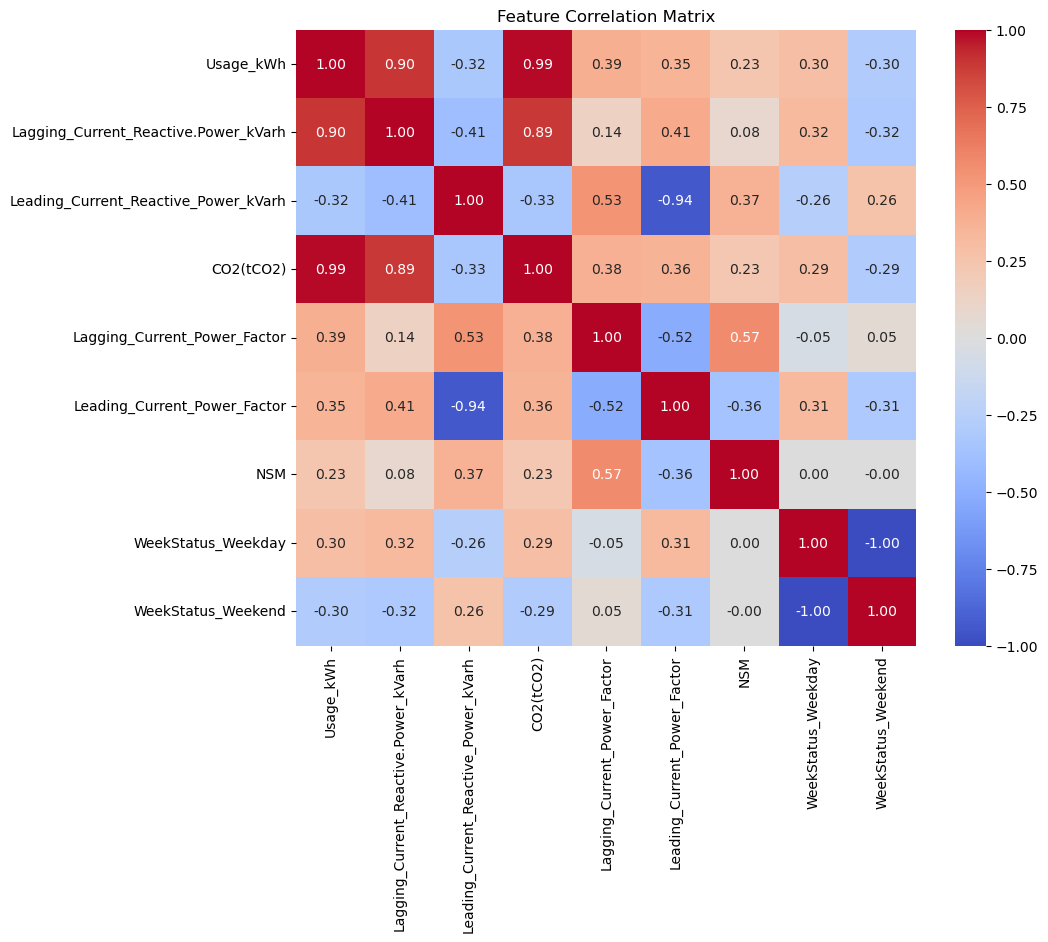

In [49]:
corr_matrix = X.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

In [45]:
X.columns

Index(['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'WeekStatus_Weekday', 'WeekStatus_Weekend'],
      dtype='object')

In [50]:
p= X.drop(columns=['WeekStatus_Weekday', 'WeekStatus_Weekend'])

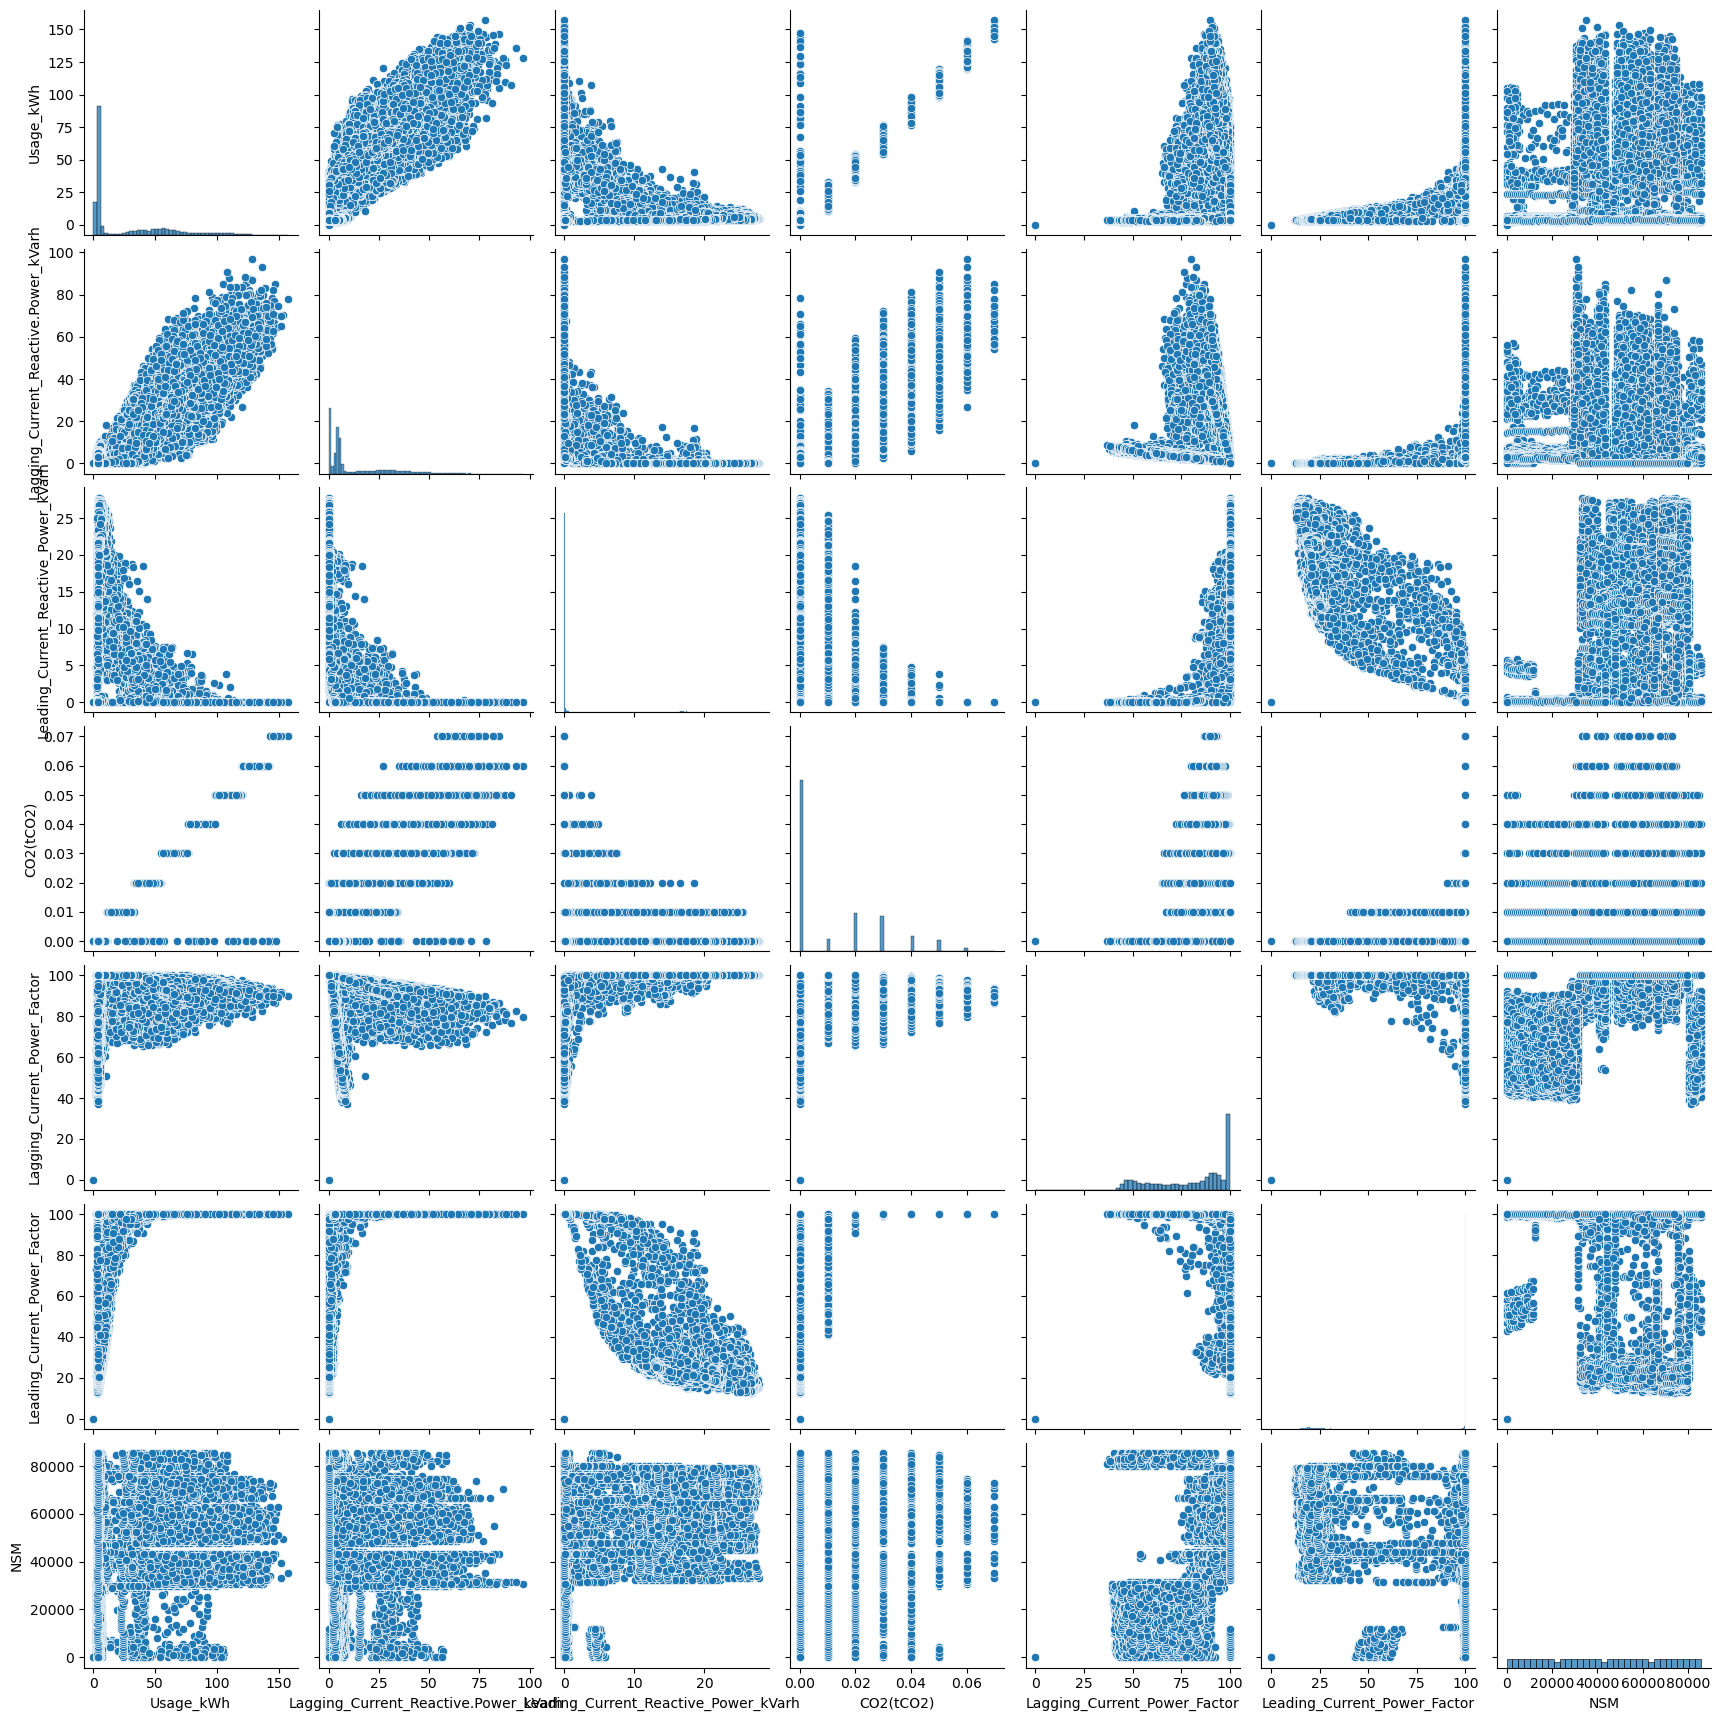

In [51]:
sns.pairplot(p)

plt.show()

Model Selection and Evaluation

In [52]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

              precision    recall  f1-score   support

           0       0.89      0.90      0.90      3615
           1       0.61      0.55      0.58      1939
           2       0.57      0.63      0.59      1454

    accuracy                           0.75      7008
   macro avg       0.69      0.69      0.69      7008
weighted avg       0.75      0.75      0.75      7008



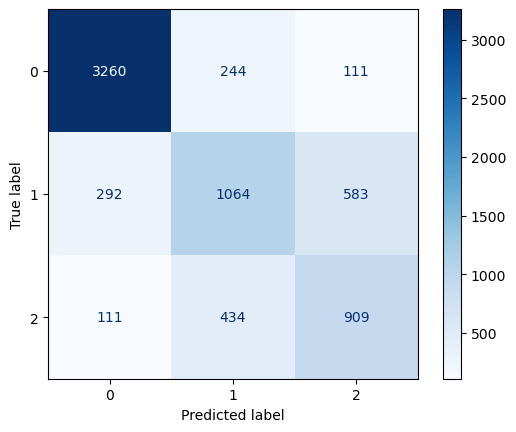

In [55]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(C =1))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])

ConfusionMatrixDisplay(
    confusion_matrix=cm
    ).plot(cmap="Blues")
plt.show()

In [51]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(
        C=1,
        max_iter=1000,
        random_state=42
    ))
])

scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring='f1_weighted'   
)

print("F1 scores:", scores)
print("Mean F1 Score:", scores.mean())

F1 scores: [0.7531267  0.7487705  0.76331712 0.75362637 0.75644039]
Mean F1 Score: 0.755056218339047


In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

param_grid = {
    'penalty': ['l2'],
    'C': [0.001, 0.01, 0.1, 1],
    'solver': ['liblinear', 'lbfgs', 'newton-cg']
}

grid = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=1000),
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',  
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)
print("Best CV F1 Score:", grid.best_score_)

C:\Users\okonk\anaconda3\Lib\site-packages\scipy\optimize\_linesearch.py:312: LineSearchWarning: The line search algorithm did not converge
  alpha_star, phi_star, old_fval, derphi_star = scalar_search_wolfe2(
C:\Users\okonk\anaconda3\Lib\site-packages\sklearn\utils\optimize.py:100: LineSearchWarning: The line search algorithm did not converge
  ret = line_search_wolfe2(


Best Parameters:
{'C': 1, 'penalty': 'l2', 'solver': 'newton-cg'}
Best CV F1 Score: 0.755176143774669



Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.95      0.95      3615
           1       0.79      0.79      0.79      1939
           2       0.78      0.80      0.79      1454

    accuracy                           0.87      7008
   macro avg       0.84      0.85      0.84      7008
weighted avg       0.87      0.87      0.87      7008



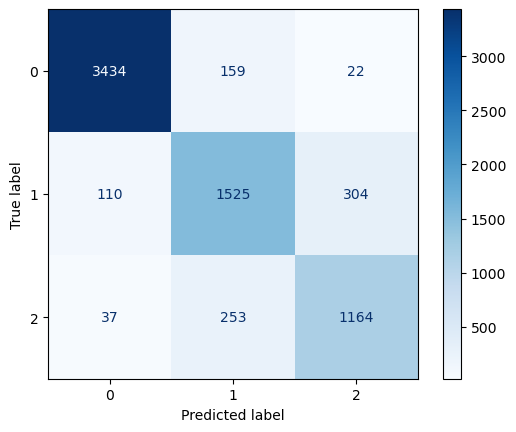

In [59]:
from sklearn.neighbors import KNeighborsClassifier
model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=11, metric="manhattan",weights="distance", p=1))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
ConfusionMatrixDisplay(
    confusion_matrix=cm
    ).plot(cmap="Blues")
plt.show()

In [60]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

model = Pipeline([
    ('scaler', StandardScaler()),
    ("knn", KNeighborsClassifier())
])


scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring='f1_weighted' 
)


print("F1 scores:", scores)
print("Mean F1 Score:", scores.mean())

F1 scores: [0.86193567 0.86622884 0.86714382 0.8581853  0.8680726 ]
Mean F1 Score: 0.8643132456008455


In [61]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11, 13],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan', 'minkowski'],
    'knn__p': [1, 2]   
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',   
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("Best CV Weighted F1 Score:", grid.best_score_)

Best Parameters:
{'knn__metric': 'manhattan', 'knn__n_neighbors': 11, 'knn__p': 1, 'knn__weights': 'distance'}
Best CV Weighted F1 Score: 0.8723937903378485


              precision    recall  f1-score   support

           0       0.89      0.97      0.93      3615
           1       0.77      0.54      0.64      1939
           2       0.67      0.78      0.72      1454

    accuracy                           0.81      7008
   macro avg       0.78      0.76      0.76      7008
weighted avg       0.81      0.81      0.80      7008



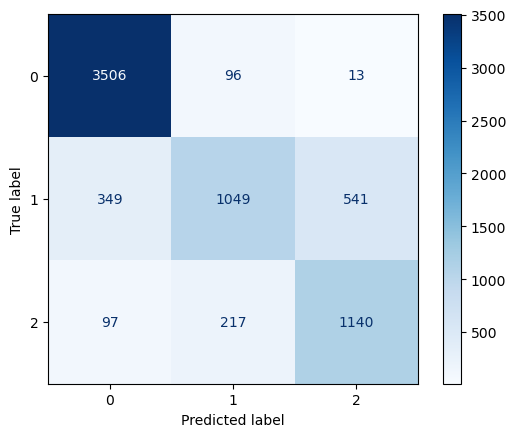

In [55]:
from sklearn.svm import SVC
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(random_state=42))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
ConfusionMatrixDisplay(
    confusion_matrix=cm
    ).plot(cmap="Blues")
plt.show()


Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      3615
           1       0.84      0.82      0.83      1939
           2       0.82      0.85      0.83      1454

    accuracy                           0.90      7008
   macro avg       0.88      0.88      0.88      7008
weighted avg       0.90      0.90      0.90      7008



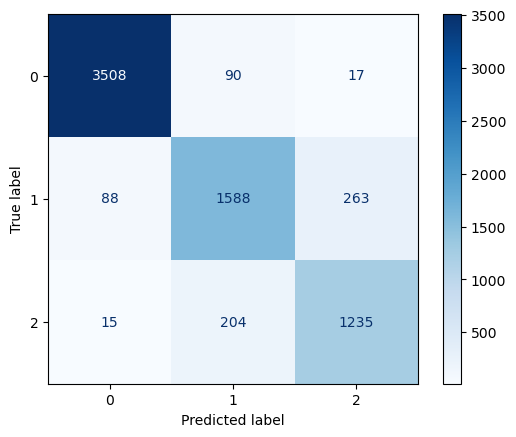

In [62]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    random_state=42,
    n_estimators=100
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
ConfusionMatrixDisplay(
    confusion_matrix=cm
    ).plot(cmap="Blues")
plt.show()

In [57]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy'],
    'max_features': ['sqrt', 'log2']
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',   
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("Best CV F1 Score:", grid.best_score_)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Best Parameters:
{'criterion': 'gini', 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1 Score: 0.903838854352915



Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      3615
           1       0.85      0.82      0.83      1939
           2       0.81      0.86      0.84      1454

    accuracy                           0.91      7008
   macro avg       0.88      0.88      0.88      7008
weighted avg       0.91      0.91      0.91      7008



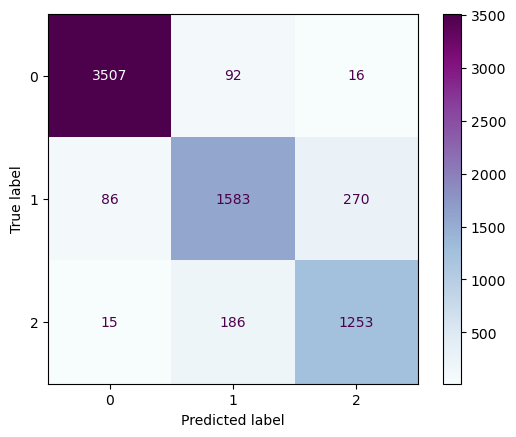

In [64]:
best_rf = grid.best_estimator_

y_pred = best_rf.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
ConfusionMatrixDisplay(
    confusion_matrix=cm
    ).plot(cmap="BuPu")
plt.show()

NSM                                     0.436257
Usage_kWh                               0.181228
Lagging_Current_Power_Factor            0.122719
Lagging_Current_Reactive.Power_kVarh    0.065707
CO2(tCO2)                               0.059249
Leading_Current_Reactive_Power_kVarh    0.055973
Leading_Current_Power_Factor            0.050213
WeekStatus_Weekend                      0.014925
WeekStatus_Weekday                      0.013730
dtype: float64


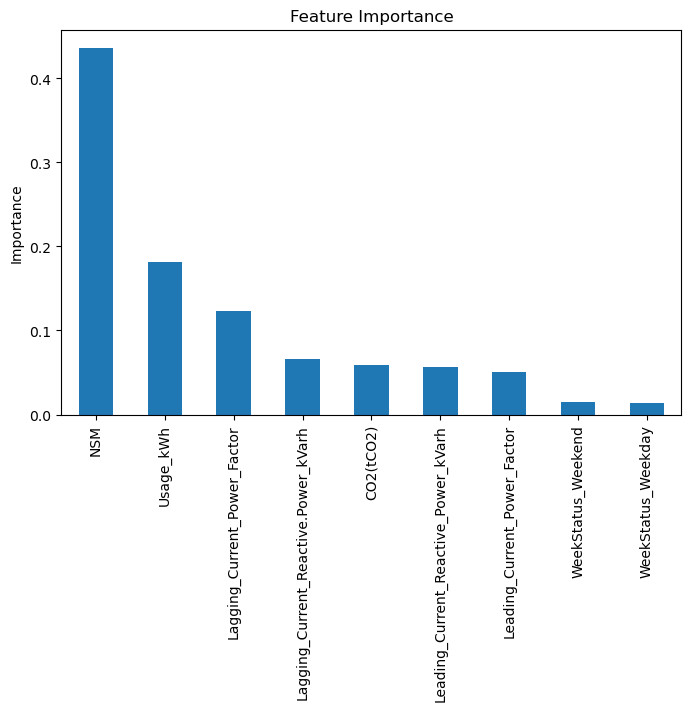

In [75]:
importance = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

plt.figure(figsize=(8,5))
importance.plot(kind="bar")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.show()